This notebooks contains program for Physics Informed Neural Network that solves for
Poisson equation on a square domain. Here we use Dirichlet conditions on all four edges. Adam optimizer is used for training.


In [34]:
from time import perf_counter
import torch
import numpy as np

In [38]:
#Neural network. Keeping minimal layers to keep the computation simple.
class FCN(torch.nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN):
        super().__init__()
        self.fcs = torch.nn.Sequential(
            torch.nn.Linear(N_INPUT, N_HIDDEN), torch.nn.Tanh(),
            torch.nn.Linear(N_HIDDEN, N_HIDDEN), torch.nn.Tanh(),
            torch.nn.Linear(N_HIDDEN, N_HIDDEN), torch.nn.Tanh(),
            torch.nn.Linear(N_HIDDEN, N_HIDDEN), torch.nn.Tanh(),
            torch.nn.Linear(N_HIDDEN, N_OUTPUT),
        )
    def forward(self, x):
        return self.fcs(x)

print("  Poisson Equation PINN Solver")
print("\nEnter boundary values (φ on each wall):") #getting input from the user for boundary conditions
bc_top    = float(input("  Top wall : "))
bc_bottom = float(input("  Bottom wall : "))
bc_left   = float(input("  Left wall  : "))
bc_right  = float(input("  Right wall : "))


# Boundary points + values
x_line = np.linspace(-0.5, 0.5, 20)
y_line = np.linspace(-0.5, 0.5, 20)
X_g, Y_g = np.meshgrid(x_line, y_line)

bc_top_xy    = np.column_stack([X_g[-1,:],  Y_g[-1,:]])
bc_bottom_xy = np.column_stack([X_g[0,:],   Y_g[0,:]])
bc_left_xy   = np.column_stack([X_g[:,0],   Y_g[:,0]])
bc_right_xy  = np.column_stack([X_g[:,-1],  Y_g[:,-1]])

bc_xy  = np.vstack([bc_top_xy, bc_bottom_xy, bc_left_xy, bc_right_xy])
bc_val = np.concatenate([
    np.full(len(bc_top_xy),    bc_top),
    np.full(len(bc_bottom_xy), bc_bottom),
    np.full(len(bc_left_xy),   bc_left),
    np.full(len(bc_right_xy),  bc_right),
])

bc_xy_t  = torch.tensor(bc_xy,  dtype=torch.float32).to(device)
bc_val_t = torch.tensor(bc_val, dtype=torch.float32).to(device)

t1_start = perf_counter()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FCN(2, 1, 20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def source_term(X, Y):
    return torch.sin(20*X) * torch.sin(20*Y)

#collocation points
random_points   = torch.rand(300, 2) - 0.5
physics_points = random_points .clone().detach().float().requires_grad_(True).to(device)


#Training
epochs = 5000 # minimal epochs are being used due to reduce the complexity

loss_container = []

for i in range(epochs):
    optimizer.zero_grad()

    physics_pred = model(physics_points)
    grad = torch.autograd.grad(physics_pred,physics_points,
                               torch.ones_like(physics_pred),
                               retain_graph=True, create_graph=True)[0]
    dx  = grad[:, 0]
    dy  = grad[:, 1]
    dx2 = torch.autograd.grad(dx,physics_points, torch.ones_like(dx), create_graph=True)[0][:, 0]
    dy2 = torch.autograd.grad(dy,physics_points, torch.ones_like(dy), create_graph=True)[0][:, 1]

    f            = source_term(physics_points[:, 0],physics_points[:, 1])
    loss_physics = torch.mean((dx2 + dy2 - f)**2)
    loss_bc      = torch.mean((model(bc_xy_t).squeeze() - bc_val_t)**2)
    loss         = 1e-2 * loss_physics + loss_bc

    loss_container.append(loss.item())
    loss.backward()
    optimizer.step()

    if i % 500 == 0:
        print(f"  Epoch {i:5d} | loss: {loss.item():.6f}")

t1_stop = perf_counter()
print(f"Time taken for training in mins: {(t1_stop - t1_start)/60:.2f} minutes")



  Poisson Equation PINN Solver

Enter boundary values (φ on each wall):
  Top wall : 0.5
  Bottom wall : 0.7
  Left wall  : 1
  Right wall : 0.9
  Epoch     0 | loss: 0.737608
  Epoch   500 | loss: 0.028676
  Epoch  1000 | loss: 0.011207
  Epoch  1500 | loss: 0.009429
  Epoch  2000 | loss: 0.009287
  Epoch  2500 | loss: 0.009072
  Epoch  3000 | loss: 0.008831
  Epoch  3500 | loss: 0.008466
  Epoch  4000 | loss: 0.008037
  Epoch  4500 | loss: 0.007601
Time taken for training in mins: 0.55 minutes


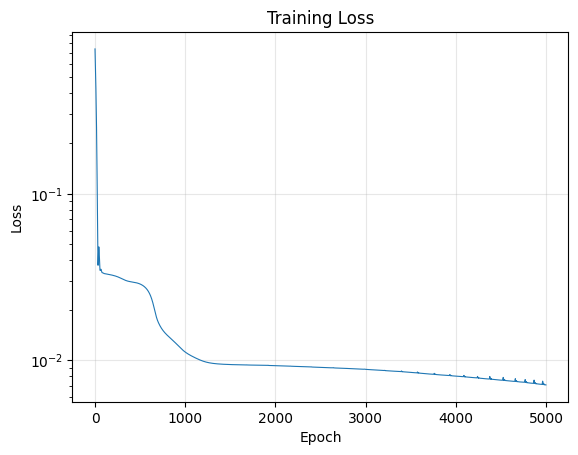

In [39]:
#loss curve
import matplotlib.pyplot as plt

plt.plot(loss_container, linewidth=0.8)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

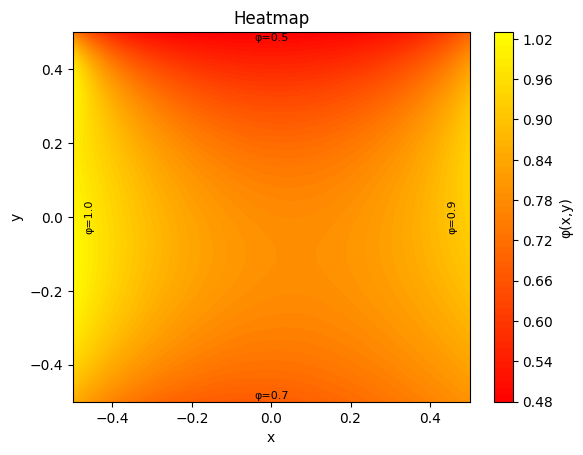

In [40]:
#heatmap
x_vis = np.linspace(-0.5, 0.5, 150)
y_vis = np.linspace(-0.5, 0.5, 150)
X_vis, Y_vis = np.meshgrid(x_vis, y_vis)
grid = torch.tensor(
    np.column_stack([X_vis.ravel(), Y_vis.ravel()]),
    dtype=torch.float32
).to(device)
with torch.no_grad():
    phi = model(grid).cpu().numpy().reshape(150, 150)
plt.figure()
cf = plt.contourf(X_vis, Y_vis, phi, levels=60, cmap=('autumn'))#GnYlRd
plt.colorbar(cf, label='φ(x,y)')
plt.title('Heatmap')
plt.xlabel('x')
plt.ylabel('y')
plt.text( 0.0,  0.47, f'φ={bc_top}',    ha='center', va='bottom', fontsize=8)
plt.text( 0.0, -0.47, f'φ={bc_bottom}', ha='center', va='top',    fontsize=8)
plt.text(-0.47, 0.0,  f'φ={bc_left}',   ha='left',   va='center', fontsize=8, rotation=90)
plt.text( 0.47, 0.0,  f'φ={bc_right}',  ha='right',  va='center', fontsize=8, rotation=90)

plt.show()